In [1]:
import sys
sys.path.insert(0, '../../')
from panel_exp.panel_data import long_df_to_paneldataset, PanelDataset, TimePeriod
from panel_exp.design import CompleteRandomization, ThinningDesign, Rerandomization, QuickBlock
from panel_exp.design.design_metrics import imbalance

from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import RidgeCV, Ridge
from panel_exp.methods.scm import SyntheticControl, AugSynth 

from panel_exp.inference import conformal
import pandas as pd
from panel_exp.methods.tbr import TBR, TBRRidge
import numpy as np

from panel_exp.inference.unit_jackknife import unit_jk, unit_jackknife, time_jackknife_plus

In [2]:
data = pd.read_csv('../data/meta_geo.csv')

In [3]:
wide_df = pd.pivot_table(data, index='location', columns='time', values='Y')
pds = PanelDataset(wide_df, [TimePeriod(start =91, end=105)
                            , TimePeriod(start =91, end=105)]
                            , ["chicago", "portland"])




In [4]:
pds.times[pds.treated_end_idxs[0]] - pds.times[pds.treated_start_idxs[0]]

14

In [5]:
pds.treated_end_idxs[0] - pds.treated_start_idxs[0]

14

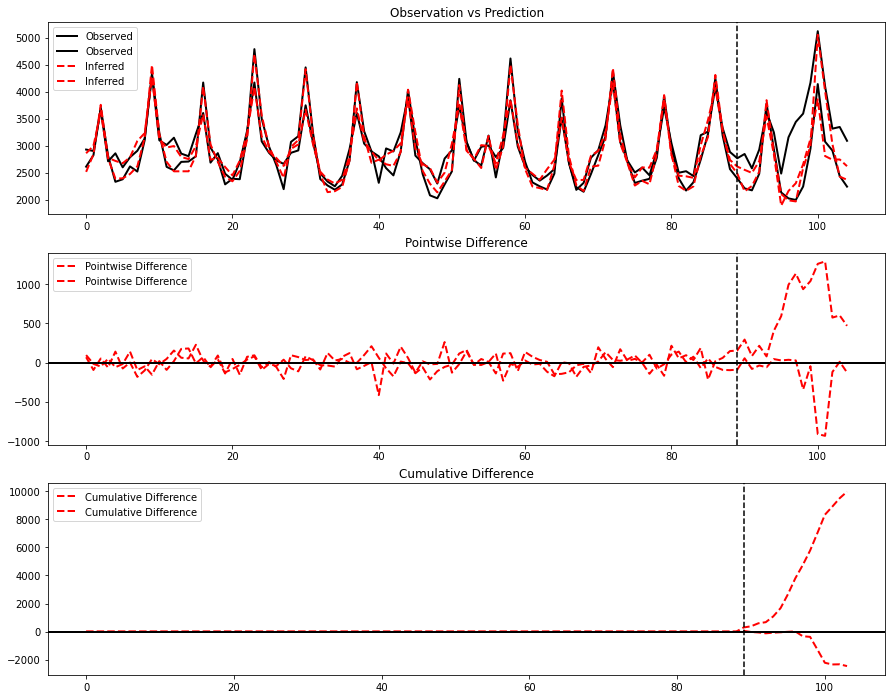

In [6]:
tbr = TBRRidge( )
tbr.run_analysis(pds)
tbr.plot()

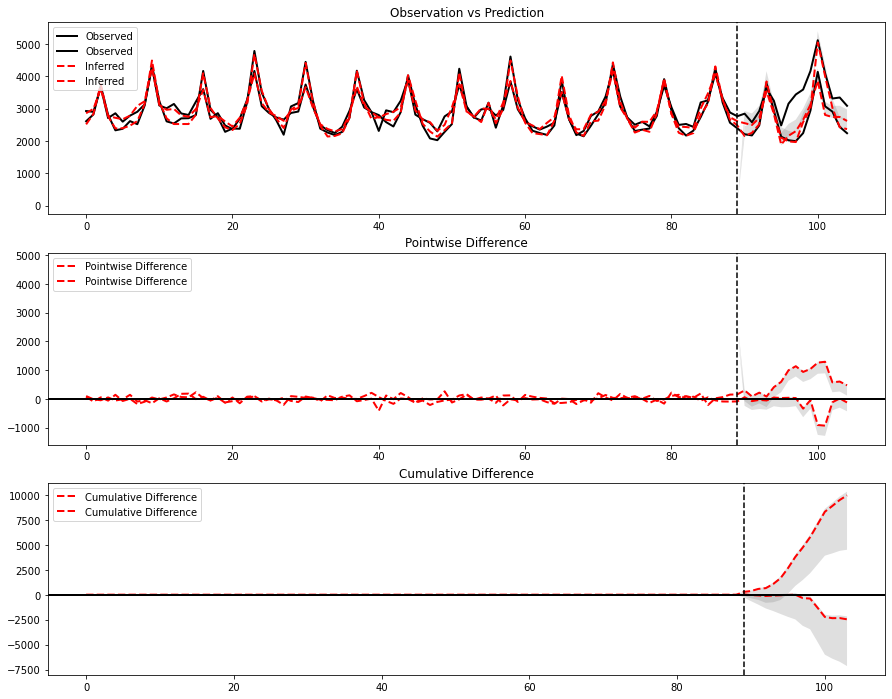

In [7]:
tbr = TBRRidge(inference='JKP')
tbr.run_analysis(pds)
tbr.plot()

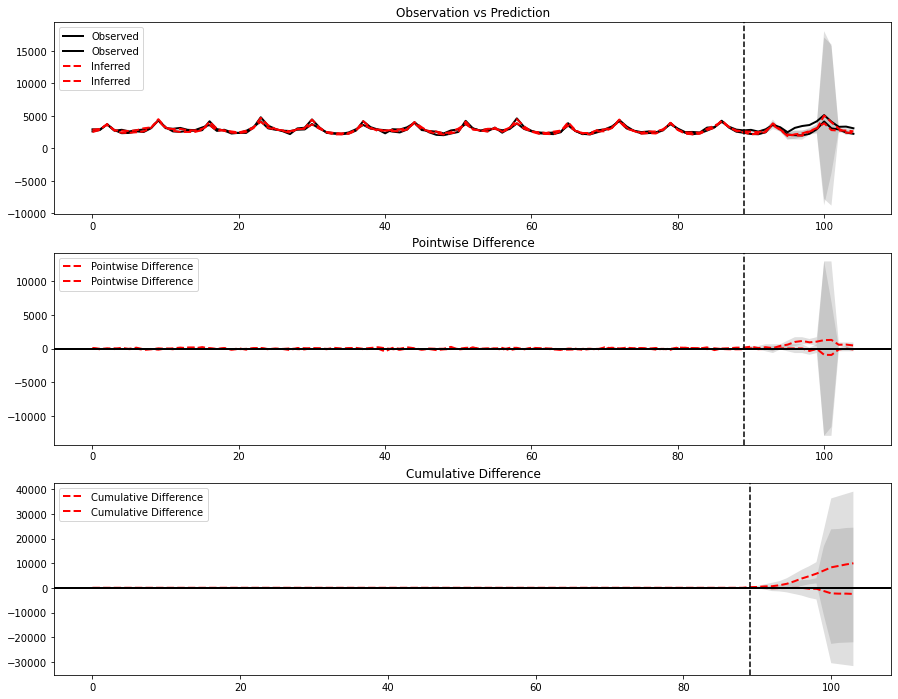

In [8]:
tbr = TBRRidge(inference='Conformal')
tbr.run_analysis(pds)
tbr.plot()

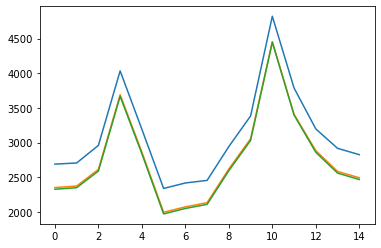

In [8]:
import matplotlib.pyplot as plt 


plt.plot(tbr.results['y_lower'].mean(axis=1)[-15:])
plt.plot(tbr.results['y_hat'].mean(axis=1)[-15:])
plt.plot(tbr.results['y_upper'].mean(axis=1)[-15:])



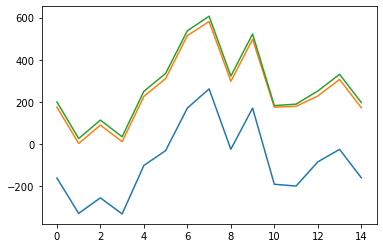

In [9]:
plt.plot(tbr.results['y'].mean(axis=1)[-15:] - tbr.results['y_lower'].mean(axis=1)[-15:])
 
plt.plot(tbr.results['y'].mean(axis=1)[-15:] - tbr.results['y_hat'].mean(axis=1)[-15:])
 
plt.plot(tbr.results['y'].mean(axis=1)[-15:] - tbr.results['y_upper'].mean(axis=1)[-15:])

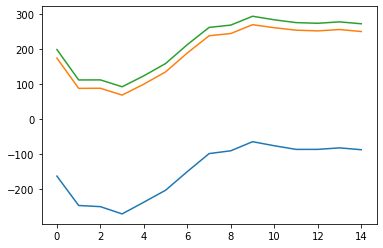

In [10]:
plt.plot((tbr.results['y'].mean(axis=1)[-15:] - tbr.results['y_lower'].mean(axis=1)[-15:]).cumsum() / range(1,16))
 
plt.plot((tbr.results['y'].mean(axis=1)[-15:] - tbr.results['y_hat'].mean(axis=1)[-15:]).cumsum() / range(1,16))
 
plt.plot((tbr.results['y'].mean(axis=1)[-15:] - tbr.results['y_upper'].mean(axis=1)[-15:]).cumsum() / range(1,16))




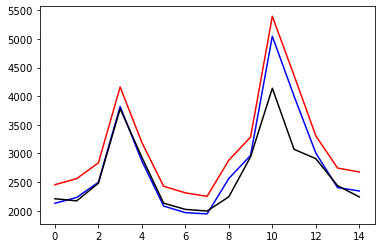

In [11]:
plt.plot(tbr.results['y_upper'][-15:][:,0], color='blue')
plt.plot(tbr.results['y_lower'][-15:][:,0], color='red')
plt.plot(tbr.results['y'][-15:][:,0], color='black')

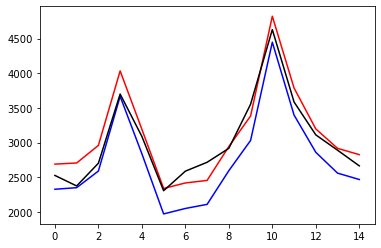

In [12]:
plt.plot(tbr.results['y_upper'][-15:].mean(axis=1), color='blue')
plt.plot(tbr.results['y_lower'][-15:].mean(axis=1), color='red')
plt.plot(tbr.results['y'][-15:].mean(axis=1), color='black')

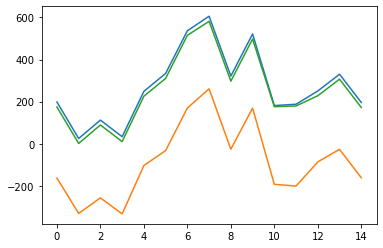

In [17]:
plt.plot(tbr.upper.mean(axis=1))
plt.plot(tbr.lower.mean(axis=1))
plt.plot(tbr.y_hat_median.mean(axis=1))

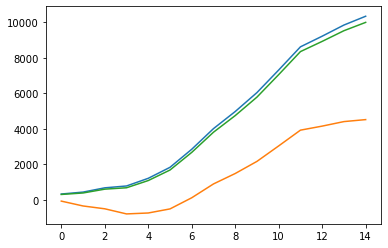

In [20]:
plt.plot(tbr.upper[:,1].cumsum())
plt.plot(tbr.lower[:,1].cumsum())
plt.plot(tbr.y_hat_median[:,1].cumsum())




In [16]:
tbr.y_hat_median.mean(axis=1)

array([174.50369886,   1.12922132,  88.89526041,   9.93255577,
       225.77495844, 310.25299707, 514.96554693, 581.85937023,
       297.37976612, 497.74376545, 175.86678583, 179.33238333,
       227.89627201, 306.5457837 , 172.01049803])

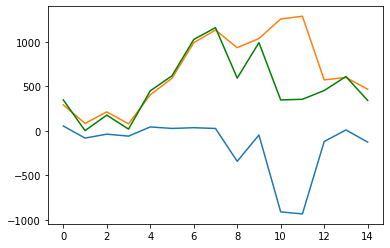

In [23]:
plt.plot((tbr.results['y']-tbr.results['y_hat'])[-15:])
plt.plot((tbr.results['y']-tbr.results['y_hat'])[-15:].sum(axis=1), color='green')

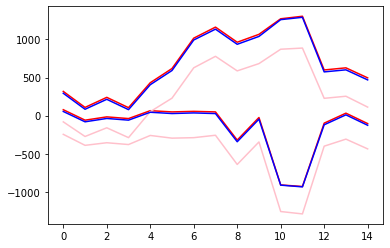

In [24]:
plt.plot(tbr.upper, color='red')
plt.plot(tbr.lower, color='pink')

plt.plot((tbr.results['y']-tbr.results['y_hat'])[-15:],color='blue')

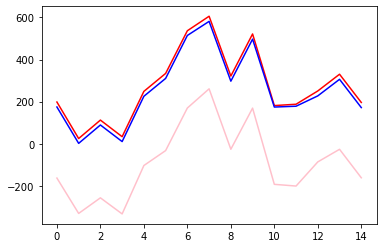

In [25]:
plt.plot(tbr.upper.mean(axis=1), color='red')
plt.plot(tbr.lower.mean(axis=1), color='pink')

plt.plot((tbr.results['y']-tbr.results['y_hat'])[-15:].mean(axis=1),color='blue')

In [26]:
print(tbr.upper.mean(axis=1).mean()*30)
print((tbr.results['y']-tbr.results['y_hat'])[-15:].mean(axis=1).mean()*15)
print(tbr.lower.mean(axis=1).mean()*30)

8163.86257039801
3757.7106123839635
-2640.678407721897


In [27]:
print(tbr.upper.mean(axis=1).cumsum())
print((tbr.results['y']-tbr.results['y_hat'])[-15:].mean(axis=1).cumsum())
print(tbr.lower.mean(axis=1).cumsum())

[ 198.0366666   222.54385532  334.69593522  367.92308589  616.54722002
  950.51181182 1487.42946657 2093.29596516 2414.82127005 2936.4802574
 3117.6123333  3305.17988396 3555.8186459  3885.99874886 4081.9312852 ]
[ 174.4230872   175.93831141  264.78330573  274.8170147   500.22957867
  810.48180248 1324.9736372  1906.38056139 2203.58777533 2700.56956554
 2874.72167639 3052.81944035 3280.083137   3586.11118656 3757.71061238]
[ -163.46655633  -495.08257558  -752.54401418 -1086.46790659
 -1190.30596407 -1223.19338451 -1053.65874842  -792.85160049
  -819.3484353   -650.24257861  -843.52762582 -1044.92417596
 -1131.53778236 -1158.25268701 -1320.33920386]


In [45]:
eff_1 = (tbr.results['y']-tbr.results['y_hat'])[-15:][:,0]
eff_2 = (tbr.results['y']-tbr.results['y_hat'])[-15:][:,1]

eff_1_up = tbr.upper[:,0]
eff_2_up = tbr.upper[:,1]

eff_1_l = tbr.lower[:,0]
eff_2_l = tbr.lower[:,1]

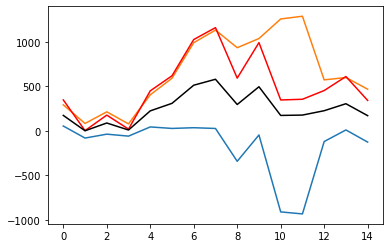

In [44]:
plt.plot(eff_1)
plt.plot(eff_2)
plt.plot(eff_1+eff_2, color='red')
plt.plot((eff_1+eff_2)/2, color='black')

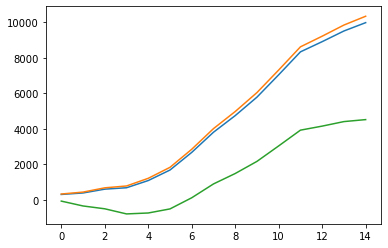

In [147]:
plt.plot(eff_2.cumsum())
plt.plot(eff_2_up.cumsum())
plt.plot(eff_2_l.cumsum())

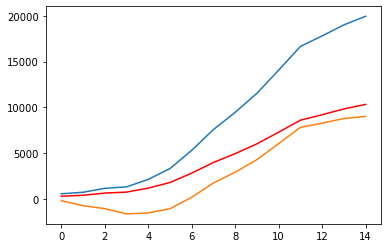

In [148]:
plt.plot(eff_2.cumsum()*2)
plt.plot(eff_2_up.cumsum(), color='red')
plt.plot(eff_2_l.cumsum()*2)

In [155]:
print(eff_2_up.mean())
print(eff_2.mean())
print(eff_2_l.mean())

688.9350997619705
664.8478862201204
300.7072507188098


In [156]:
print(eff_1_up.mean())
print(eff_1.mean())
print(eff_1_l.mean())

-144.67759506876976
-163.81980456892526
-476.75247790026964


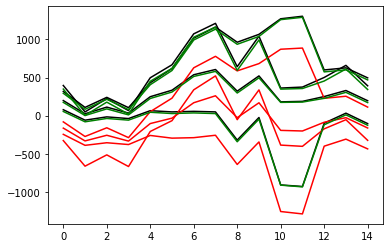

In [51]:
plt.plot(eff_1_up,color='black')
plt.plot(eff_2_up,color='black')
plt.plot(eff_1_up+eff_2_up, color='black')
plt.plot((eff_1_up+eff_2_up)/2, color='black')

plt.plot(eff_1_l, color='red')
plt.plot(eff_2_l, color='red')
plt.plot(eff_1_l+eff_2_l, color='red')
plt.plot((eff_1_l+eff_2_l)/2, color='red')

plt.plot(eff_1, color='green')
plt.plot(eff_2, color='green')
plt.plot(eff_1+eff_2, color='green')
plt.plot((eff_1+eff_2)/2, color='green')

In [125]:
wide_df = pd.pivot_table(data, index='location', columns='time', values='Y')
pds = PanelDataset(wide_df, [TimePeriod(start =91, end=105) ]
                            , ["chicago"])

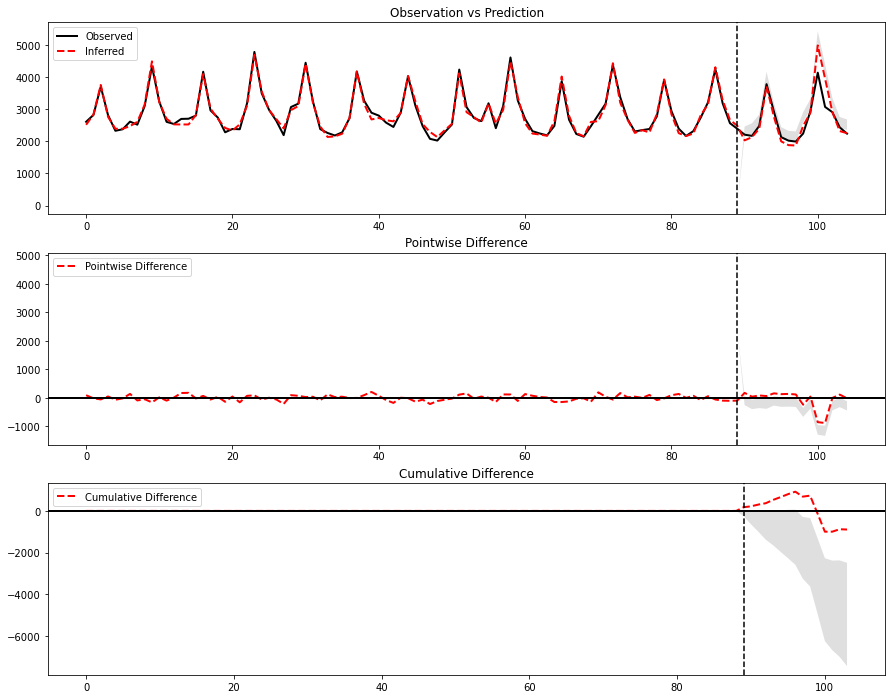

In [126]:
tbr = TBRRidge(inference='JKP')
tbr.run_analysis(pds)
tbr.plot()

In [150]:
panel=pds
pre_t_time = panel.treated_start_idxs[0]-1
n_treated_units = len(panel.treated_units)
n_treated_time_periods = (panel.treated_end_idxs[0] - panel.treated_start_idxs[0])+1

lower_df = np.zeros((pre_t_time
          , n_treated_time_periods
          , n_treated_units))

upper_df = np.zeros((pre_t_time
          , n_treated_time_periods
          , n_treated_units))

for t_unit in range(pre_t_time):

    # drop t unit from pre-treatment periods
    new_wide_df = panel.wide_data.drop(panel.times[t_unit], axis=1)

    # append to end
    new_wide_df = new_wide_df.assign(new_column = panel.wide_data.loc[:, panel.times[t_unit]]).rename(columns={"new_column": panel.times[-1]+1})

    # new PDS
    new_pds = PanelDataset(new_wide_df
                           , [TimePeriod(start=tp.start, end=resolve_end_period(tp)) for tp in panel.treated_periods]
                           , panel.treated_units)
    # fit new model 
    model = TBRRidge( )
    model.run_analysis(new_pds)

    residuals = model.results['y'][new_pds.treated_start_idxs[0]:] - model.results['y_hat'][new_pds.treated_start_idxs[0]:]
    error = np.abs(residuals[-1])

    upper = (residuals[:-1] + error).reshape(n_treated_time_periods,n_treated_units)
    lower = (residuals[:-1] - error).reshape(n_treated_time_periods,n_treated_units)

    lower_df[t_unit] += lower
    upper_df[t_unit] += upper


In [12]:
def resolve_end_period(time_period):
    """
    Helper function for resolving time index when end is None. 
    """
    if time_period.end is None:
        return None
    else:
        return time_period.end+1
    

In [152]:
residuals[:-1]

array([[   46.67848644,   306.46548353],
       [ -108.6270641 ,   126.14818955],
       [  -51.96634987,   237.52246616],
       [  -96.39618748,   135.95627262],
       [   35.9289445 ,   419.43103152],
       [   34.19133084,   582.9492054 ],
       [   25.77276004,  1008.43915085],
       [   35.31569303,  1123.35432497],
       [ -346.10216354,   942.41563053],
       [  -63.25605422,  1066.15485824],
       [-1143.77953995,  1612.59831446],
       [-1111.63671621,  1559.77719929],
       [ -157.32282066,   631.27184554],
       [  -14.40089402,   639.52306686],
       [ -153.23918442,   510.5010139 ]])

In [153]:
error


array([181.79310689, 276.39841308])

In [154]:
residuals[:-1]+error

array([[ 228.47159334,  582.86389662],
       [  73.1660428 ,  402.54660264],
       [ 129.82675703,  513.92087925],
       [  85.39691941,  412.3546857 ],
       [ 217.7220514 ,  695.82944461],
       [ 215.98443773,  859.34761848],
       [ 207.56586693, 1284.83756393],
       [ 217.10879993, 1399.75273805],
       [-164.30905664, 1218.81404362],
       [ 118.53705268, 1342.55327133],
       [-961.98643305, 1888.99672755],
       [-929.84360931, 1836.17561238],
       [  24.47028624,  907.67025862],
       [ 167.39221288,  915.92147994],
       [  28.55392248,  786.89942698]])

In [31]:
((np.percentile(upper_df, 50, axis=0)  + np.percentile(lower_df, 50, axis=0) ) / n_treated_units).mean(axis=1)

array([172.31824684,  -1.92906735,  85.94924601,   7.33981928,
       226.5541146 , 306.75398271, 518.65633614, 586.40132705,
       300.50243453, 498.68178035, 171.72622128, 177.13615142,
       230.83470085, 305.97736436, 169.88694023])

In [27]:
# Pre-Aggregate
wide = wide_df
treated = ["chicago", "portland"]

control_units = pd.DataFrame(wide.loc[[c for c in wide.index if c not in treated]].mean(axis=0), columns=['controls']).T
treated_units = pd.DataFrame(wide.loc[treated].mean(axis=0), columns=['treated']).T

wide_agg = pd.concat([treated_units, control_units])
panel_data = PanelDataset(wide_agg, treated_units = ['treated'], treated_periods=[TimePeriod(start =91, end=105)])


In [10]:
panel_data


        Panel Dataset Summary
        ---------------------
        Number of time points: 105
        Number of units: 2
        Number of treated units: 1
        Treated units: ['treated']
        Treated periods: [TimePeriod(start=91, end=105)]
        

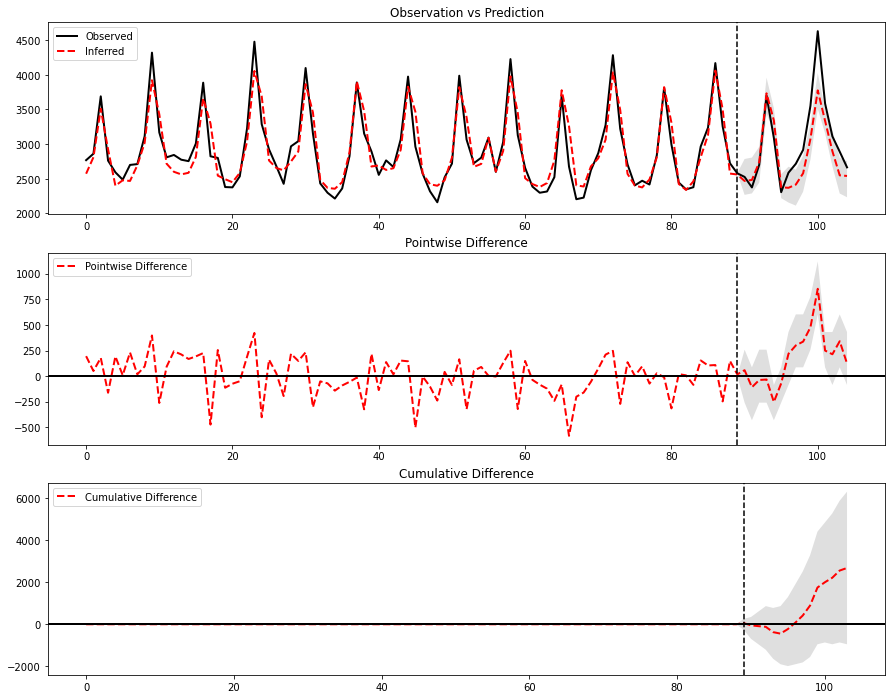

In [11]:
tbr = TBR(inference='Conformal')
tbr.run_analysis(panel_data)
tbr.plot()


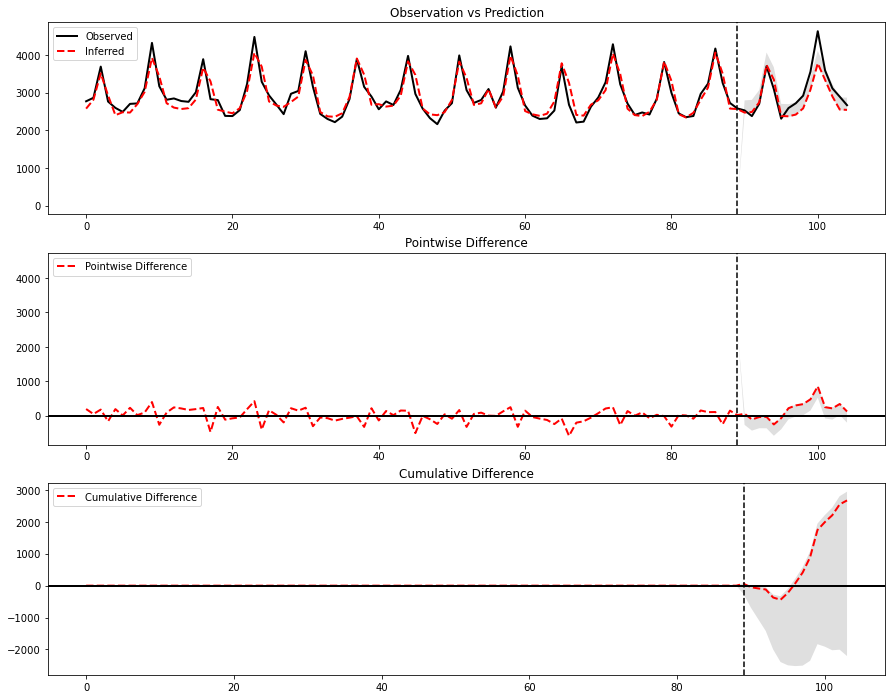

In [12]:
tbr = TBR(inference='JKP')
tbr.run_analysis(panel_data)
tbr.plot()

In [13]:
pds


        Panel Dataset Summary
        ---------------------
        Number of time points: 105
        Number of units: 40
        Number of treated units: 2
        Treated units: ['chicago', 'portland']
        Treated periods: [TimePeriod(start=91, end=105), TimePeriod(start=91, end=105)]
        